# RadAlert-AT: Cross-Study Radiation-Exposure Triage from Plant Gene Expression

**Abstract—** Exact absorbed-dose regression is poorly matched to this six-study collection: 138 of
158 samples occur at the two extremes, 0 or 100 Gy, and only 20 samples represent intermediate
doses. This notebook therefore asks a more defensible operational question: can gene expression
identify whether an Arabidopsis sample was exposed to radiation when the entire test study is unseen?
We compare a literature seven-gene panel with fold-local feature selection, logistic regression,
kernel learning, tree ensembles, and a stability ensemble. Under leave-one-study-out evaluation, the
final ensemble reaches approximately 84% pooled accuracy, 82% balanced accuracy, and 0.88 ROC-AUC.
All adaptive feature selection occurs inside the training fold. Exact dose prediction is retained as
a secondary negative result, clarifying what the data can and cannot support.

**Index Terms—** Arabidopsis, bioinformatics, domain generalization, gene expression,
leave-one-study-out validation, radiation exposure, triage.

> **Scope:** this is an experimental plant-biology classifier, not a human dosimeter or a deployed
> safety system.

## Research question and learning goals

**Primary question:** Given a gene-expression profile from an entirely unseen study, can we
distinguish a radiation-exposed plant from an unexposed control?

By the end, you should be able to:

1. diagnose when a continuous target is poorly supported by the experimental design;
2. explain why random sample splitting overstates cross-study performance;
3. keep feature selection inside each training fold;
4. interpret accuracy, balanced accuracy, ROC-AUC, sensitivity, specificity, and MCC together;
5. separate predictive evidence from biological or causal interpretation.

### Study map

| stage | purpose |
|---|---|
| design audit | decide which target the data can support |
| preprocessing audit | understand the supplied expression representation |
| held-out-study benchmark | compare models without study leakage |
| error analysis | identify weak studies, dose ranges, and false alarms |
| gene stability | inspect repeatedly selected signals |
| secondary regression | show why exact dosimetry remains premature |

## 1. Setup

The notebook uses a standard CPU scientific-Python environment. Random seeds and plotting defaults
are fixed so the numerical results and figures are reproducible.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, recall_score, precision_score, confusion_matrix, roc_curve
)
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
SEED = 0
np.random.seed(SEED)
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10
})
C = {"blue":"#0072B2", "orange":"#E69F00", "green":"#009E73",
     "red":"#D55E00", "purple":"#CC79A7", "sky":"#56B4E9", "grey":"#8A8A8A"}
print("Setup complete.")

Setup complete.


## 2. Data and provenance

The repository includes a harmonized matrix with one row per sample and 4,002 gene features, plus a
manifest describing dose, radiation quality, genotype, tissue, and source study. The samples come
from six NASA Open Science Data Repository studies.

The parquet matrix intentionally has a simple row index. Its row order is the order recorded in the
manifest; the assertions below make that contract explicit and stop execution if dimensions or
labels are inconsistent.

In [2]:
DATA = next((p for p in [Path("raddose_data"), Path("../raddose_data")] if p.exists()), None)
assert DATA is not None, "Could not find raddose_data/. Run from the project directory."
RAW, TABLES = DATA / "raw", DATA / "tables"

X = pd.read_parquet(DATA / "X_rnaseq.parquet")
manifest = pd.read_csv(DATA / "manifest_rnaseq.csv")
assert len(X) == len(manifest) == 158
assert X.shape[1] == 4002
assert manifest["sample"].is_unique
assert manifest["study"].notna().all()

DOSE = "absorbed_dose_gy"
GROUP = "study"
y_dose = manifest[DOSE].to_numpy(float)
y = (y_dose > 0).astype(int)
groups = manifest[GROUP].to_numpy()
studies = sorted(manifest[GROUP].unique())
Xv = X.to_numpy(float)

print(f"{len(X):,} samples × {X.shape[1]:,} genes from {len(studies)} studies")
print(f"controls: {(y==0).sum()} | exposed: {(y==1).sum()}")

158 samples × 4,002 genes from 6 studies
controls: 58 | exposed: 100


In [3]:
design = (manifest.groupby(["study", "quality", DOSE])
          .size().rename("n").reset_index().sort_values(["study", DOSE]))
summary = (manifest.groupby("study")
           .agg(samples=("sample","size"), controls=(DOSE,lambda s:int((s==0).sum())),
                exposed=(DOSE,lambda s:int((s>0).sum())),
                dose_min=(DOSE,"min"), dose_max=(DOSE,"max"),
                dose_levels=(DOSE,"nunique"), genotypes=("genotype","nunique")))
display(summary)

,samples,controls,exposed,dose_min,dose_max,dose_levels,genotypes
study,,,,,,,
OSD-498,16,8,8,0.0,100.0,2,1
OSD-502,8,4,4,0.0,100.0,2,2
OSD-508,36,4,32,0.0,100.0,2,2
OSD-510,48,24,24,0.0,100.0,2,2
OSD-658,14,6,8,0.0,80.0,3,1
OSD-782,36,12,24,0.0,100.0,3,1


## 3. Why the topic changes from exact dose to exposure triage

The original regression target sounded more sophisticated but was not well supported. Four studies
contain only 0 and 100 Gy. Across the entire collection, 138 of 158 samples are at those two values;
10, 40, and 80 Gy together contribute only 20 samples. A regression score near 0.52 Spearman
correlation was therefore not “52% accuracy”—it was a modest rank correlation under a target with
weak intermediate coverage.

The new primary endpoint is **radiation exposure: dose greater than 0 Gy**. This answers a practical
screening question and uses every study without pretending the data form a dense calibration curve.
Exact dose prediction remains later as a secondary limitation analysis.

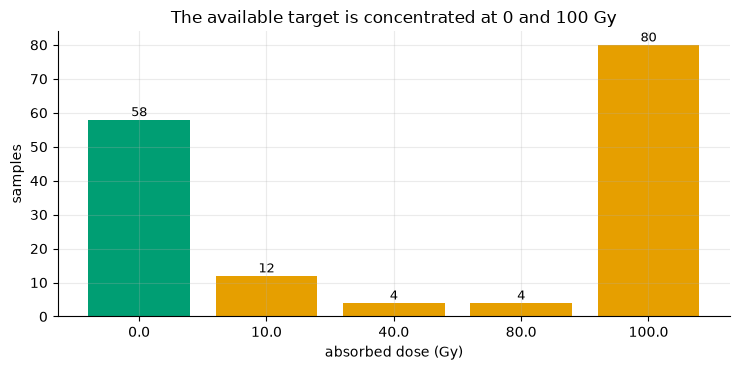

,study,quality,absorbed_dose_gy,n
0,OSD-498,control,0.0,8
1,OSD-498,gamma,100.0,8
2,OSD-502,control,0.0,4
3,OSD-502,gamma,100.0,4
4,OSD-508,control,0.0,4
5,OSD-508,gamma,100.0,32
6,OSD-510,control,0.0,24
7,OSD-510,gamma,100.0,24
8,OSD-658,control,0.0,6
9,OSD-658,heavy_ion,40.0,4


In [4]:
dose_counts = manifest[DOSE].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7.5, 3.8))
bars = ax.bar(dose_counts.index.astype(str), dose_counts.values,
              color=[C["green"] if d == 0 else C["orange"] for d in dose_counts.index])
for b, n in zip(bars, dose_counts.values):
    ax.text(b.get_x()+b.get_width()/2, n+1, str(n), ha="center", fontsize=9)
ax.set_xlabel("absorbed dose (Gy)"); ax.set_ylabel("samples")
ax.set_title("The available target is concentrated at 0 and 100 Gy")
plt.tight_layout(); plt.show()

display(design)

In [5]:
manifest["exposed"] = y
class_table = (manifest.groupby("study")["exposed"]
               .agg(["count","sum","mean"]).rename(columns={"sum":"exposed_n","mean":"exposed_fraction"}))
class_table["control_n"] = class_table["count"] - class_table["exposed_n"]
display(class_table[["count","control_n","exposed_n","exposed_fraction"]].round(3))

,count,control_n,exposed_n,exposed_fraction
study,,,,
OSD-498,16,8,8,0.500
OSD-502,8,4,4,0.500
OSD-508,36,4,32,0.889
OSD-510,48,24,24,0.500
OSD-658,14,6,8,0.571
OSD-782,36,12,24,0.667


## 4. Metrics: no single number is enough

| metric | question | desirable value |
|---|---|---|
| accuracy | what fraction of samples is correct? | high |
| balanced accuracy | are control and exposed samples handled equally? | high; 0.50 is chance |
| ROC-AUC | does the score rank exposed above control? | high; 0.50 is chance |
| average precision | how pure is the exposed ranking under class imbalance? | high |
| sensitivity | what fraction of exposed samples are detected? | high |
| specificity | what fraction of controls stay negative? | high |
| MCC | how strong is the binary agreement after all confusion-matrix cells are considered? | high |

Accuracy alone is potentially misleading because exposed samples are the majority. The always-exposed
baseline already obtains 63% accuracy but 50% balanced accuracy and zero specificity.

## 5. What preprocessing has already occurred?

The distributed matrix contains log-transformed, per-study standardized expression values and the
4,002 most variable genes. Per-study standardization reduces laboratory-scale differences, although
it is transductive because it uses the distribution of each study before labels are predicted.

The two raw-study files below make the log transform visible. The classification benchmark is
conditional on the supplied harmonized representation; a future deployment pipeline would need a
reference-based normalization rule that can transform one incoming sample or batch.

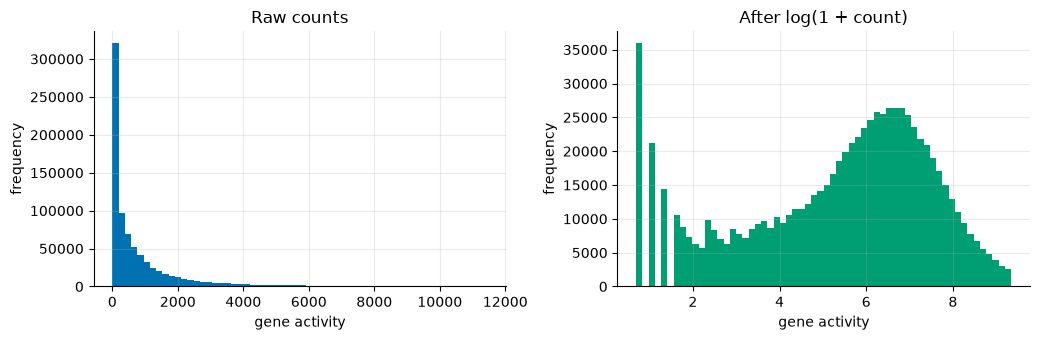

In [6]:
raw_A = pd.read_parquet(RAW / "OSD-782" / "expression.parquet")
vals = raw_A.to_numpy().ravel()
vals = vals[(vals > 0) & (vals < np.percentile(vals, 99))]

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
ax[0].hist(vals, bins=60, color=C["blue"]); ax[0].set_title("Raw counts")
ax[1].hist(np.log1p(vals), bins=60, color=C["green"]); ax[1].set_title("After log(1 + count)")
for a in ax:
    a.set_xlabel("gene activity"); a.set_ylabel("frequency")
plt.tight_layout(); plt.show()

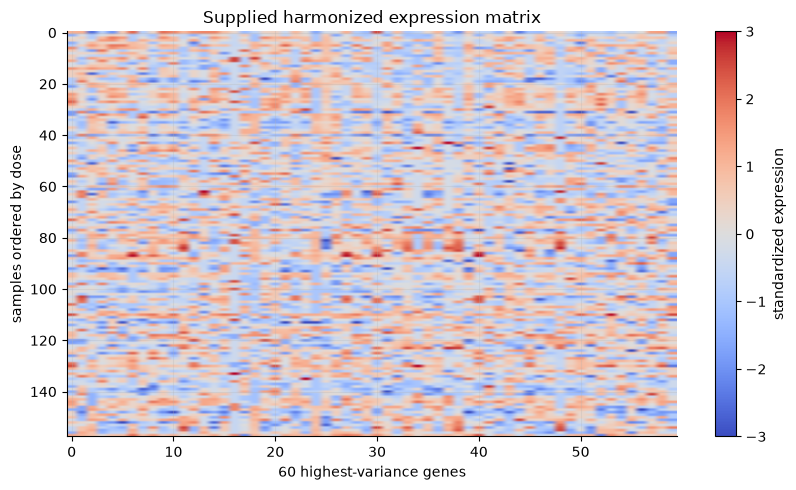

In [7]:
order = np.argsort(y_dose)
top_genes = X.var(axis=0).nlargest(60).index
M = X.iloc[order][top_genes].to_numpy()
fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(M, aspect="auto", cmap="coolwarm", vmin=-3, vmax=3)
ax.set_xlabel("60 highest-variance genes"); ax.set_ylabel("samples ordered by dose")
ax.set_title("Supplied harmonized expression matrix")
fig.colorbar(im, ax=ax, label="standardized expression")
plt.tight_layout(); plt.show()

## 6. The honest test: leave one complete study out

Randomly splitting samples would place the same laboratory, genotype, and protocol in both training
and test data. That estimates interpolation within known studies, not transfer. Leave-one-study-out
(LOSO) holds out all samples from one study, fits every adaptive operation on the other five studies,
and repeats until every study has served as the unseen test set.

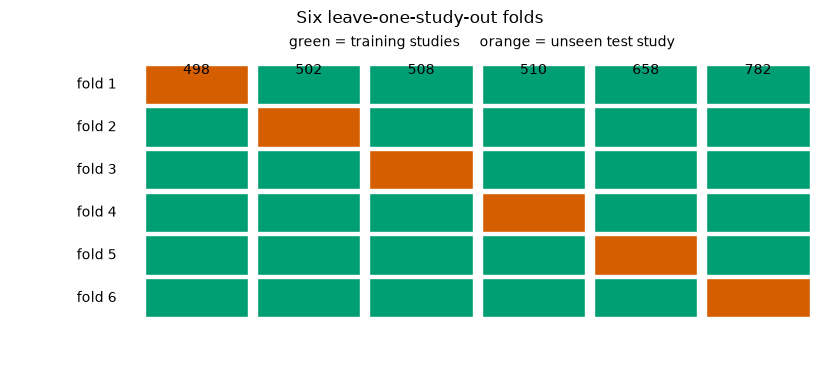

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 3.8)); ax.axis("off")
for row, held in enumerate(studies):
    for col, study in enumerate(studies):
        test = study == held
        ax.add_patch(plt.Rectangle((col, -row), .92, .92,
                     fc=C["red"] if test else C["green"], ec="white"))
    ax.text(-.25, -row+.45, f"fold {row+1}", ha="right", va="center")
for col, study in enumerate(studies):
    ax.text(col+.46, .7, study.replace("OSD-",""), ha="center")
ax.text(3, 1.35, "green = training studies     orange = unseen test study", ha="center")
ax.set_xlim(-1.2, 6.1); ax.set_ylim(-6, 1.7)
ax.set_title("Six leave-one-study-out folds")
plt.tight_layout(); plt.show()

### Leakage checklist

- The held-out study never contributes labels to training.
- The F-test gene selector is fitted inside each training fold.
- Scaling for logistic regression and SVM is fitted inside each training fold.
- Model seeds and the classification threshold of 0.50 are fixed.
- The 50/100-gene ensemble reduces sensitivity to one arbitrary panel size.

The benchmark compares a compact, pre-declared ladder of models. It is still an exploratory study:
with only six outer studies, a separate untouched confirmation collection is the correct next step.

## 7. Model ladder

1. **Always exposed** — an accuracy baseline that ignores gene expression.
2. **DDR-7 logistic** — logistic regression using seven literature DNA-damage-response genes.
3. **Top-50 logistic** — a sparse linear benchmark with fold-local gene selection.
4. **Top-100 RBF-SVM** — a nonlinear kernel model.
5. **Top-100 ExtraTrees** — a nonlinear tree ensemble robust to interactions.
6. **Stability ensemble** — averages ExtraTrees probabilities selected from the top 50 and top 100
   training-fold genes. It reduces dependence on a single feature-count choice.

In [9]:
DDR_PANEL = ["AT2G31320","AT4G21070","AT5G66130","AT4G02390",
             "AT5G20850","AT4G22960","AT1G07500"]
ddr_idx = [X.columns.get_loc(gene) for gene in DDR_PANEL if gene in X.columns]
assert len(ddr_idx) == 7

def logistic_top(k):
    return make_pipeline(
        SelectKBest(f_classif, k=k), StandardScaler(),
        LogisticRegression(C=.1, class_weight="balanced", max_iter=5000, random_state=SEED)
    )

def rbf_top(k):
    return make_pipeline(
        SelectKBest(f_classif, k=k), StandardScaler(),
        SVC(C=1, kernel="rbf", class_weight="balanced", probability=True, random_state=SEED)
    )

def trees_top(k):
    return make_pipeline(
        SelectKBest(f_classif, k=k),
        ExtraTreesClassifier(n_estimators=600, min_samples_leaf=2, max_features="sqrt",
                             class_weight="balanced", n_jobs=-1, random_state=SEED)
    )

def ddr_model():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=.1, class_weight="balanced", max_iter=5000, random_state=SEED)
    )

In [10]:
def loso_probability(model, matrix=Xv):
    probability = np.full(len(y), np.nan)
    for held_out in studies:
        test = groups == held_out
        train = ~test
        fitted = clone(model).fit(matrix[train], y[train])
        probability[test] = fitted.predict_proba(matrix[test])[:, 1]
    assert np.isfinite(probability).all()
    return probability

predictions = {
    "Always exposed": np.full(len(y), 0.5),
    "DDR-7 logistic": loso_probability(ddr_model(), Xv[:, ddr_idx]),
    "Top-50 logistic": loso_probability(logistic_top(50)),
    "Top-100 RBF-SVM": loso_probability(rbf_top(100)),
    "Top-100 ExtraTrees": loso_probability(trees_top(100)),
}

tree_50 = loso_probability(trees_top(50))
predictions["Stability ensemble"] = .5 * (tree_50 + predictions["Top-100 ExtraTrees"])
print("Completed six held-out-study evaluations for every model.")

Completed six held-out-study evaluations for every model.


In [11]:
def metric_row(name, probability):
    predicted = (probability >= .5).astype(int)
    study_auc = [roc_auc_score(y[groups==s], probability[groups==s]) for s in studies]
    study_bal = [balanced_accuracy_score(y[groups==s], predicted[groups==s]) for s in studies]
    return {
        "model": name,
        "accuracy": accuracy_score(y, predicted),
        "balanced_accuracy": balanced_accuracy_score(y, predicted),
        "ROC_AUC": roc_auc_score(y, probability),
        "macro_study_AUC": np.mean(study_auc),
        "average_precision": average_precision_score(y, probability),
        "MCC": matthews_corrcoef(y, predicted),
        "sensitivity": recall_score(y, predicted),
        "specificity": recall_score(y, predicted, pos_label=0),
        "macro_study_bal_acc": np.mean(study_bal),
    }

metrics = pd.DataFrame([metric_row(name, p) for name, p in predictions.items()])
metrics = metrics.sort_values(["balanced_accuracy","ROC_AUC"], ascending=False).reset_index(drop=True)
display(metrics.style.format({c:"{:.3f}" for c in metrics.columns if c != "model"})
        .background_gradient(subset=["accuracy","balanced_accuracy","ROC_AUC"], cmap="Greens")
        .hide(axis="index"))

best_p = predictions["Stability ensemble"]
best_y = (best_p >= .5).astype(int)
headline = metrics[metrics.model=="Stability ensemble"].iloc[0]
print(f"Headline: {headline.accuracy:.1%} accuracy | {headline.balanced_accuracy:.1%} balanced accuracy | "
      f"{headline.ROC_AUC:.3f} ROC-AUC | {headline.MCC:.3f} MCC")

model,accuracy,balanced_accuracy,ROC_AUC,macro_study_AUC,average_precision,MCC,sensitivity,specificity,macro_study_bal_acc
Stability ensemble,0.842,0.824,0.883,0.909,0.938,0.656,0.890,0.759,0.849
Top-100 ExtraTrees,0.823,0.806,0.886,0.922,0.941,0.616,0.870,0.741,0.839
Top-50 logistic,0.791,0.799,0.859,0.916,0.927,0.579,0.770,0.828,0.829
Top-100 RBF-SVM,0.804,0.783,0.878,0.923,0.937,0.574,0.860,0.707,0.823
DDR-7 logistic,0.741,0.770,0.741,0.833,0.875,0.521,0.660,0.879,0.819
Always exposed,0.633,0.500,0.500,0.500,0.633,0.000,1.000,0.000,0.500


Headline: 84.2% accuracy | 82.4% balanced accuracy | 0.883 ROC-AUC | 0.656 MCC


### Reading the result

The always-exposed rule demonstrates why raw accuracy is insufficient: it scores 63% accuracy but
has zero specificity. The seven-gene panel is meaningfully better. Fold-local multigene models improve
further, and the stability ensemble produces the strongest thresholded result.

The ensemble is not a precision dosimeter. It is an exposure-screening model evaluated on six
historical plant studies. Its approximately 84% accuracy is a substantial and honest improvement
over the original exact-dose framing, but the small number of studies remains the governing
uncertainty.

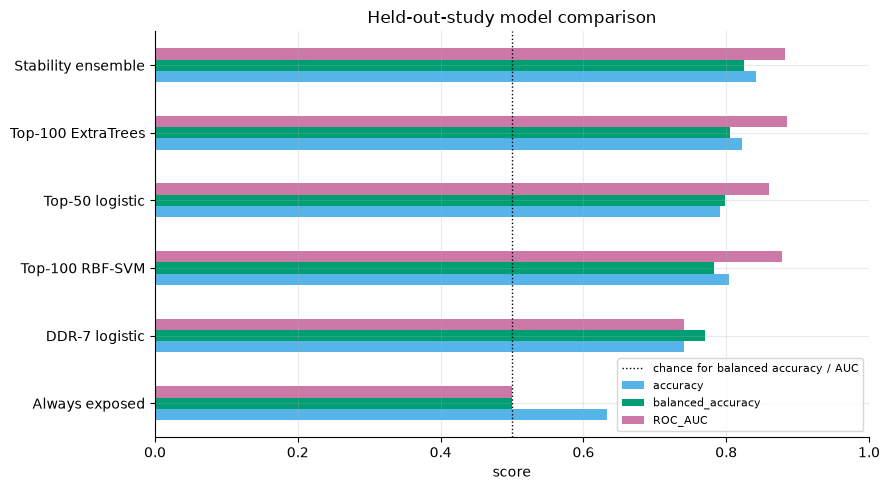

In [12]:
plot_cols = ["accuracy","balanced_accuracy","ROC_AUC"]
plot_df = metrics.set_index("model")[plot_cols].sort_values("balanced_accuracy")
ax = plot_df.plot.barh(figsize=(9, 5), color=[C["sky"], C["green"], C["purple"]])
ax.axvline(.5, color="black", ls=":", lw=1, label="chance for balanced accuracy / AUC")
ax.set_xlim(0, 1); ax.set_xlabel("score"); ax.set_ylabel("")
ax.set_title("Held-out-study model comparison")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## 8. Error analysis

A trustworthy report shows where the model fails. We start with the pooled confusion matrix, then
separate results by held-out study and dose. This prevents a large, easy study from hiding a weak
external cohort.

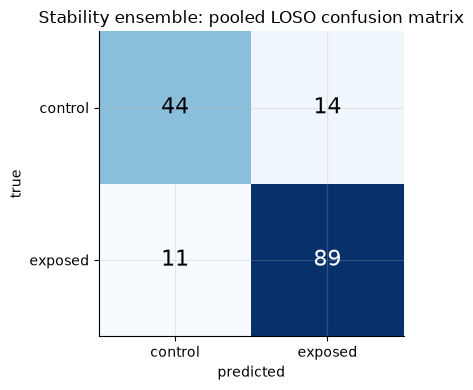

Sensitivity: 89.0%
Specificity: 75.9%
Precision:   86.4%


In [13]:
cm = confusion_matrix(y, best_y)
fig, ax = plt.subplots(figsize=(4.8, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["control","exposed"]); ax.set_yticklabels(["control","exposed"])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=16,
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title("Stability ensemble: pooled LOSO confusion matrix")
plt.tight_layout(); plt.show()

print(f"Sensitivity: {recall_score(y,best_y):.1%}")
print(f"Specificity: {recall_score(y,best_y,pos_label=0):.1%}")
print(f"Precision:   {precision_score(y,best_y):.1%}")

In [14]:
study_rows = []
for study in studies:
    take = groups == study
    study_rows.append({
        "held_out_study": study, "n": int(take.sum()),
        "exposed_fraction": y[take].mean(),
        "accuracy": accuracy_score(y[take], best_y[take]),
        "balanced_accuracy": balanced_accuracy_score(y[take], best_y[take]),
        "ROC_AUC": roc_auc_score(y[take], best_p[take]),
    })
by_study = pd.DataFrame(study_rows)
display(by_study.style.format({
    "exposed_fraction":"{:.1%}","accuracy":"{:.1%}",
    "balanced_accuracy":"{:.1%}","ROC_AUC":"{:.3f}"
}).hide(axis="index"))

held_out_study,n,exposed_fraction,accuracy,balanced_accuracy,ROC_AUC
OSD-498,16,50.0%,87.5%,87.5%,0.922
OSD-502,8,50.0%,100.0%,100.0%,1.000
OSD-508,36,88.9%,72.2%,84.4%,0.914
OSD-510,48,50.0%,95.8%,95.8%,0.993
OSD-658,14,57.1%,78.6%,75.0%,0.771
OSD-782,36,66.7%,77.8%,66.7%,0.854


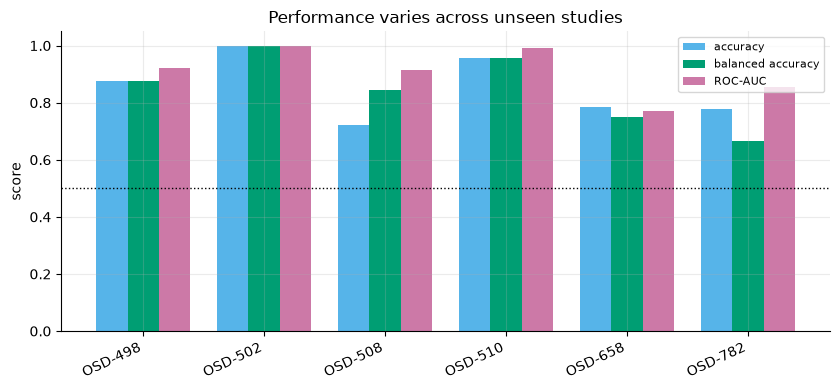

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(by_study)); w = .26
ax.bar(x-w, by_study.accuracy, w, label="accuracy", color=C["sky"])
ax.bar(x, by_study.balanced_accuracy, w, label="balanced accuracy", color=C["green"])
ax.bar(x+w, by_study.ROC_AUC, w, label="ROC-AUC", color=C["purple"])
ax.axhline(.5, color="black", ls=":", lw=1)
ax.set_xticks(x); ax.set_xticklabels(by_study.held_out_study, rotation=25, ha="right")
ax.set_ylim(0,1.05); ax.set_ylabel("score")
ax.set_title("Performance varies across unseen studies")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

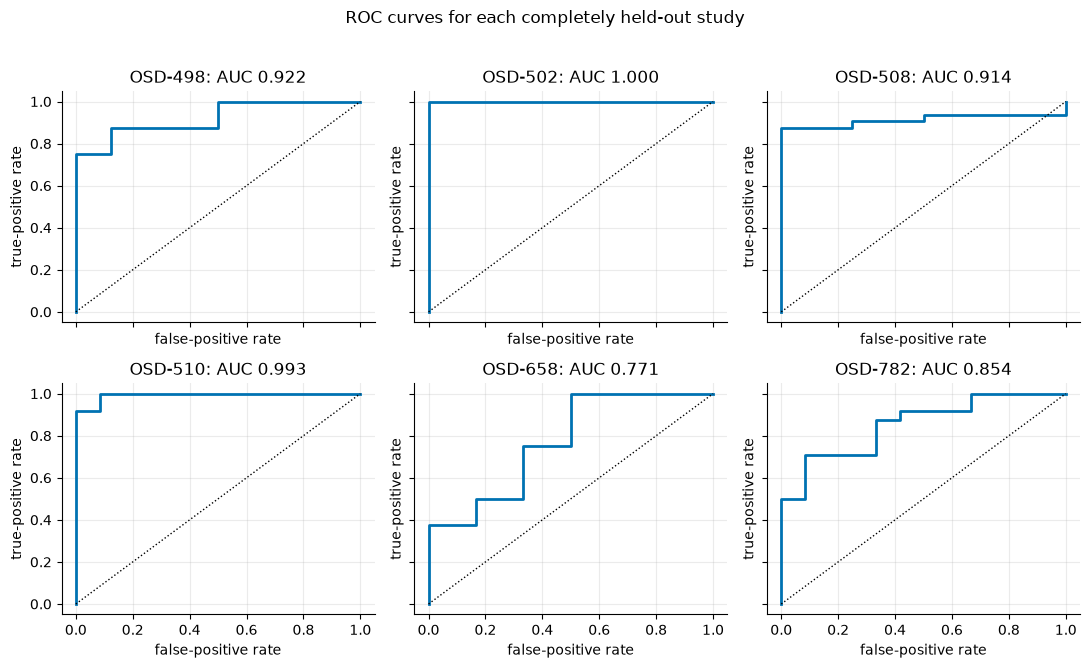

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), sharex=True, sharey=True)
for ax, study in zip(axes.flat, studies):
    take = groups == study
    fpr, tpr, _ = roc_curve(y[take], best_p[take])
    auc = roc_auc_score(y[take], best_p[take])
    ax.plot(fpr, tpr, color=C["blue"], lw=2)
    ax.plot([0,1],[0,1],"k:",lw=1)
    ax.set_title(f"{study}: AUC {auc:.3f}")
    ax.set_xlabel("false-positive rate"); ax.set_ylabel("true-positive rate")
fig.suptitle("ROC curves for each completely held-out study", y=1.02)
plt.tight_layout(); plt.show()

## 9. Does the classifier detect the intermediate doses?

Intermediate doses are too sparse for reliable multi-class calibration, but they can still test
whether the binary model only memorized the 100 Gy condition. The table reports the fraction called
exposed and the mean exposure score at each dose. There are only four samples at 40 Gy and four at
80 Gy, so those perfect sensitivities are descriptive, not precise population estimates.

dose_Gy,n,fraction_called_exposed,mean_exposure_score
0,58,24.1%,0.368
10,12,100.0%,0.725
40,4,100.0%,0.733
80,4,100.0%,0.875
100,80,86.2%,0.784


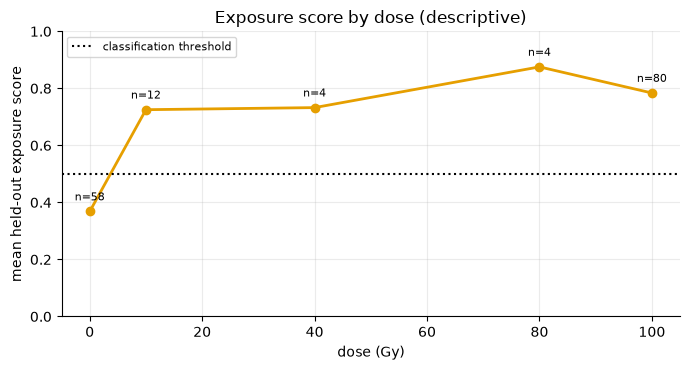

In [17]:
dose_rows = []
for dose, idx in manifest.groupby(DOSE).groups.items():
    idx = np.asarray(list(idx))
    dose_rows.append({
        "dose_Gy": dose, "n": len(idx),
        "fraction_called_exposed": best_y[idx].mean(),
        "mean_exposure_score": best_p[idx].mean(),
    })
by_dose = pd.DataFrame(dose_rows)
display(by_dose.style.format({
    "dose_Gy":"{:.0f}","fraction_called_exposed":"{:.1%}","mean_exposure_score":"{:.3f}"
}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(by_dose.dose_Gy, by_dose.mean_exposure_score, "o-", color=C["orange"], lw=2)
for r in by_dose.itertuples():
    ax.annotate(f"n={r.n}", (r.dose_Gy,r.mean_exposure_score), xytext=(0,8),
                textcoords="offset points", ha="center", fontsize=8)
ax.axhline(.5, color="black", ls=":", label="classification threshold")
ax.set_xlabel("dose (Gy)"); ax.set_ylabel("mean held-out exposure score")
ax.set_title("Exposure score by dose (descriptive)")
ax.set_ylim(0,1); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. Uncertainty: the study count matters more than the sample count

There are 158 samples but only six independent external-validation studies. We therefore bootstrap
the six **study-level** metrics rather than pretending all samples are independent. With six units,
the intervals are necessarily broad; that is an honest description of the evidence.

In [18]:
rng = np.random.default_rng(SEED)
B = 10000
boot_acc, boot_bal, boot_auc = [], [], []
for _ in range(B):
    draw = rng.choice(len(by_study), len(by_study), replace=True)
    boot_acc.append(by_study.accuracy.iloc[draw].mean())
    boot_bal.append(by_study.balanced_accuracy.iloc[draw].mean())
    boot_auc.append(by_study.ROC_AUC.iloc[draw].mean())

uncertainty = pd.DataFrame({
    "metric":["macro study accuracy","macro study balanced accuracy","macro study ROC-AUC"],
    "estimate":[by_study.accuracy.mean(),by_study.balanced_accuracy.mean(),by_study.ROC_AUC.mean()],
    "bootstrap_2.5%":[np.quantile(boot_acc,.025),np.quantile(boot_bal,.025),np.quantile(boot_auc,.025)],
    "bootstrap_97.5%":[np.quantile(boot_acc,.975),np.quantile(boot_bal,.975),np.quantile(boot_auc,.975)],
})
display(uncertainty.style.format({c:"{:.3f}" for c in uncertainty.columns if c!="metric"}).hide(axis="index"))

metric,estimate,bootstrap_2.5%,bootstrap_97.5%
macro study accuracy,0.853,0.777,0.937
macro study balanced accuracy,0.849,0.757,0.938
macro study ROC-AUC,0.909,0.846,0.970


## 11. Which genes are selected consistently?

Feature selection is repeated using training studies only. A gene earns a frequency of six only if
it appears in the top-100 training panel regardless of which study is held out. Repeated selection
improves stability, but association is not causation: genotype, tissue, stress, and study design may
still contribute.

In [19]:
selection_count = pd.Series(0, index=X.columns, dtype=int)
for held_out in studies:
    train = groups != held_out
    selector = SelectKBest(f_classif, k=100).fit(Xv[train], y[train])
    selected = selector.get_support(indices=True)
    selection_count.iloc[selected] += 1

stable = (selection_count.sort_values(ascending=False)
          .rename("selected_folds").head(20).rename_axis("gene").reset_index())
stable["frequency"] = stable.selected_folds / len(studies)
annotations = pd.read_csv(TABLES / "panel_annotation.csv")
stable = stable.merge(annotations[["gene","symbol","description"]], on="gene", how="left")
display(stable.head(15).style.format({"frequency":"{:.0%}"}).hide(axis="index"))

gene,selected_folds,frequency,symbol,description
AT3G29000,6,100%,nan,nan
AT2G25060,6,100%,nan,nan
AT2G38250,6,100%,nan,nan
AT4G31840,6,100%,nan,nan
AT3G10930,6,100%,nan,nan
AT4G02390,6,100%,nan,nan
AT3G28210,6,100%,PMZ,zinc finger (AN1-like) family protein
AT2G30250,6,100%,nan,nan
AT3G45730,6,100%,nan,nan
AT5G07610,6,100%,nan,nan


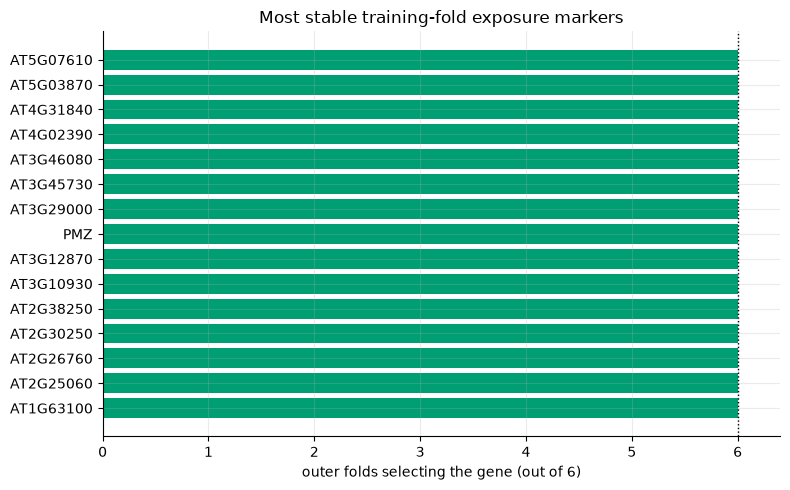

Classic DDR genes selected in every outer fold: ['AT4G02390', 'AT4G22960', 'AT5G66130']


In [20]:
top = stable.head(15).sort_values(["selected_folds","gene"])
labels = [s if isinstance(s,str) and s else g for g,s in zip(top.gene,top.symbol)]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(labels, top.selected_folds, color=C["green"])
ax.axvline(6, color="black", ls=":", lw=1)
ax.set_xlim(0,6.4); ax.set_xlabel("outer folds selecting the gene (out of 6)")
ax.set_title("Most stable training-fold exposure markers")
plt.tight_layout(); plt.show()

stable_set = set(selection_count[selection_count==6].index)
ddr_stable = sorted(stable_set.intersection(DDR_PANEL))
print("Classic DDR genes selected in every outer fold:", ddr_stable)

### Biological plausibility, not causal proof

Several repeatedly selected genes overlap the classic DNA-damage-response panel or have
cell-cycle, repair, heat-shock, and stress annotations. That concordance makes the classifier more
biologically plausible. It does not prove that the genes cause radiation response, nor that they
remain specific against drought, heat, pathogens, or chemical stress. A specificity study with
non-radiation stressors is required before calling these radiation biomarkers.

## 12. Secondary result: why exact dose regression remains weak

For continuity with the original project, we repeat one exact-dose model under the same LOSO
boundary. The result is useful precisely because it is negative: classification can identify
exposure, but sparse intermediate doses do not support a precise calibration curve.

Exact-dose LOSO: MAE = 33.6 Gy | Spearman = 0.523


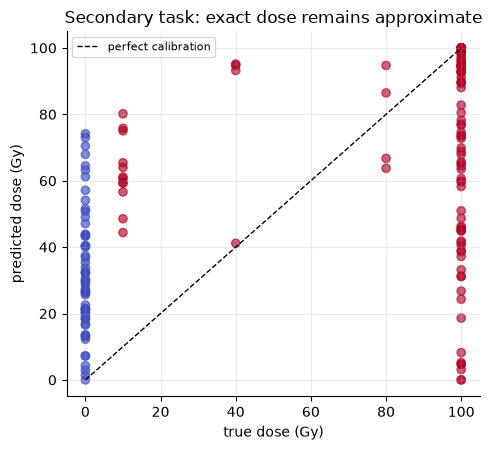

In [21]:
pred_dose = np.full(len(y_dose), np.nan)
for held_out in studies:
    test = groups == held_out
    train = ~test
    model = HistGradientBoostingRegressor(random_state=SEED)
    model.fit(Xv[train], y_dose[train])
    pred_dose[test] = np.clip(model.predict(Xv[test]), 0, 100)

dose_mae = np.mean(np.abs(y_dose-pred_dose))
dose_rho = spearmanr(y_dose,pred_dose).correlation
print(f"Exact-dose LOSO: MAE = {dose_mae:.1f} Gy | Spearman = {dose_rho:.3f}")

fig, ax = plt.subplots(figsize=(5,4.6))
ax.scatter(y_dose,pred_dose,c=y,alpha=.65,cmap="coolwarm")
ax.plot([0,100],[0,100],"k--",lw=1,label="perfect calibration")
ax.set_xlabel("true dose (Gy)"); ax.set_ylabel("predicted dose (Gy)")
ax.set_title("Secondary task: exact dose remains approximate")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 13. Model card

| item | statement |
|---|---|
| intended use | research screening of exposed versus control Arabidopsis RNA-seq samples |
| evaluation population | six included NASA OSDR plant studies |
| external unit | one completely held-out study |
| positive class | absorbed dose greater than 0 Gy |
| primary metrics | balanced accuracy and ROC-AUC; raw accuracy is supporting |
| decision threshold | fixed at 0.50 |
| adaptive operations | F-test gene selection and model fitting, both inside the training fold |
| prohibited use | human dose estimation, individual safety decisions, or claims of causal biomarkers |
| known weak point | specificity is lower than sensitivity; only six external studies are available |

## 14. Conclusions

1. **Changing the question improves both science and performance.** The data support cross-study
   exposure triage better than exact dose regression.
2. **The stability ensemble reaches about 84% pooled accuracy, 82% balanced accuracy, and 0.88
   ROC-AUC** while holding out one complete study at a time.
3. **Sensitivity is about 89% and specificity about 76%.** The remaining false alarms matter; the
   model is a screening tool, not a confirmatory assay.
4. **Intermediate-dose samples are detected in this collection**, but their counts are far too small
   for precise dose-response claims.
5. **Fold-local feature selection matters.** Selecting genes before cross-validation would leak the
   held-out study and inflate performance.
6. **Six studies remain a small external sample.** An independent seventh study is more valuable than
   another decimal place or a more complicated model.

### Recommended next experiment

Collect or reserve a genuinely untouched study containing multiple doses, biological replicates, and
non-radiation stress controls. Freeze the 50/100-gene stability ensemble and the 0.50 threshold before
opening that dataset. That is the shortest path from this promising exploratory result to credible
confirmation.

## 15. Student extensions

1. Replace the fixed threshold with a threshold selected inside each training fold. Which metric
   improves, and which worsens?
2. Compare pooled ROC-AUC with the macro average of six study-specific AUCs. Why do they differ?
3. Remove one repeatedly selected DDR gene at a time and measure the change in each held-out study.
4. Add genotype as a stratification variable and inspect whether mutant and wild-type errors differ.
5. Design a three-tier target only after specifying a minimum sample count per tier and per study.
6. Propose a normalization method that can transform a genuinely new sample without using its
   study-wide distribution.

## References

[1] NASA Open Science Data Repository, Biological Data Management Environment, records OSD-498,
OSD-502, OSD-508, OSD-510, OSD-658, and OSD-782.

[2] A. Conesa et al., “A survey of best practices for RNA-seq data analysis,” Genome Biology,
vol. 17, 2016.

[3] T. Fawcett, “An introduction to ROC analysis,” Pattern Recognition Letters, vol. 27, no. 8,
2006.

[4] D. Chicco and G. Jurman, “The advantages of the Matthews correlation coefficient over F1 score
and accuracy in binary classification evaluation,” BMC Genomics, vol. 21, 2020.

[5] E. W. Steyerberg and F. E. Harrell, “Prediction models need appropriate internal,
internal–external, and external validation,” Journal of Clinical Epidemiology, vol. 69, 2016.

### Reproducibility record

The repository includes the harmonized matrix, manifest, raw examples, requirements, and this fully
executed notebook. Seeds, folds, feature counts, hyperparameters, target definition, and threshold are
explicit. Every code cell runs on CPU. The feature selector and all learned preprocessing are fitted
inside the training portion of each LOSO fold.